# LightGBM SHAP Explainability — Notebook

This notebook loads the trained LightGBM model, computes SHAP values on a sample of
the test set, and produces global (summary bar, beeswarm) and local (per-case)
explanations for high-risk predictions.

Run `08_train_lightgbm_model_colab.ipynb` first so the model file exists, then run
this notebook top to bottom.

Note: the original script called `matplotlib.use("Agg")` to force headless plotting
(no on-screen display). In this notebook that line is omitted so `plt.show()` can
render figures inline.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import shap
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

print("Imports OK")

Imports OK


## 1. Configure paths

Update `WORKSPACE_ROOT` below if your workspace isn't auto-detected (e.g. if you mounted
Google Drive, point it at the Drive folder containing `data/processed/...`).

In [2]:
def find_workspace_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()

    for path in [current, *current.parents]:
        if (path / "data" / "processed" / "baseline_modeling_dataset.csv.gz").exists():
            return path

    return current


WORKSPACE_ROOT = find_workspace_root()

# --- If auto-detection doesn't find your dataset (common in Colab), set it manually: ---
# WORKSPACE_ROOT = Path("/content/drive/MyDrive/your-project-folder")

DATASET_FILE = WORKSPACE_ROOT / "data" / "processed" / "baseline_modeling_dataset.csv.gz"
MODEL_FILE = WORKSPACE_ROOT / "ml" / "model_artifacts" / "lightgbm_fraud_model.joblib"
REPORTS_DIR = WORKSPACE_ROOT / "reports" / "model_reports"
FIGURES_DIR = WORKSPACE_ROOT / "reports" / "figures"
SHAP_IMPORTANCE_FILE = REPORTS_DIR / "lightgbm_shap_feature_importance.csv"
LOCAL_EXPLANATIONS_FILE = REPORTS_DIR / "lightgbm_local_explanations.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2
SHAP_SAMPLE_SIZE = 2000
LOCAL_CASE_COUNT = 5
TOP_LOCAL_FEATURES = 10

print(f"WORKSPACE_ROOT: {WORKSPACE_ROOT}")
print(f"DATASET_FILE:   {DATASET_FILE}  (exists: {DATASET_FILE.exists()})")
print(f"MODEL_FILE:     {MODEL_FILE}  (exists: {MODEL_FILE.exists()})")

WORKSPACE_ROOT: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai
DATASET_FILE:   C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\data\processed\baseline_modeling_dataset.csv.gz  (exists: True)
MODEL_FILE:     C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\ml\model_artifacts\lightgbm_fraud_model.joblib  (exists: True)


In [3]:
def create_output_directories() -> None:
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)


create_output_directories()
print("Output directories ready:")
for d in [REPORTS_DIR, FIGURES_DIR]:
    print(f"  - {d}")

Output directories ready:
  - C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports
  - C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures


## 2. Load the dataset

In [4]:
def load_dataset() -> tuple[pd.DataFrame, pd.Series]:
    if not DATASET_FILE.exists():
        raise FileNotFoundError(
            f"Processed dataset not found: {DATASET_FILE}. "
            "Run ml/src/features/build_baseline_feature_dataset.py first."
        )

    df = pd.read_csv(DATASET_FILE)
    target = df["isFraud"]
    features = df.drop(columns=["isFraud"])
    return features, target


features, target = load_dataset()
print(f"Features shape: {features.shape}")
print(f"Target shape:   {target.shape}")
print(f"Fraud rate:     {target.mean():.4%}")

Features shape: (590540, 81)
Target shape:   (590540,)
Fraud rate:     3.4990%


## 3. Load the trained LightGBM model

In [5]:
def load_model():
    if not MODEL_FILE.exists():
        raise FileNotFoundError(
            f"LightGBM model not found: {MODEL_FILE}. "
            "Run ml/src/models/train_lightgbm_model.py first."
        )
    return joblib.load(MODEL_FILE)


model_pipeline = load_model()
print(f"Model loaded from: {MODEL_FILE}")
model_pipeline

Model loaded from: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\ml\model_artifacts\lightgbm_fraud_model.joblib


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](81,)","['TransactionAmt','ProductCD','card1',...,'email_domain_match', 'card_missing_count','address_missing_count']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,81
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'d

## 4. Recreate the test split

Uses the same `random_state` and `test_size` as training, so this reproduces the
exact held-out test set the model was evaluated on.

In [6]:
_, X_test, _, y_test = train_test_split(
    features,
    target,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=target,
)

print(f"X_test: {X_test.shape}   y_test fraud rate: {y_test.mean():.4%}")

X_test: (118108, 81)   y_test fraud rate: 3.4993%


## 5. Sample the test set

SHAP is computed on a random sample of the test set for speed, capped at
`SHAP_SAMPLE_SIZE` rows.

In [7]:
sample_size = min(SHAP_SAMPLE_SIZE, len(X_test))
X_sample = X_test.sample(n=sample_size, random_state=RANDOM_STATE)
print(f"SHAP sample size: {sample_size} rows (out of {len(X_test)} test rows)")

SHAP sample size: 2000 rows (out of 118108 test rows)


## 6. Feature-name and transform helpers

In [8]:
def get_feature_names(model_pipeline) -> list[str]:
    preprocessor = model_pipeline.named_steps["preprocessor"]
    try:
        feature_names = preprocessor.get_feature_names_out()
        return [str(feature) for feature in feature_names]
    except Exception:
        classifier = model_pipeline.named_steps["classifier"]
        return [f"feature_{index}" for index in range(len(classifier.feature_importances_))]


def transform_features(model_pipeline, features: pd.DataFrame):
    preprocessor = model_pipeline.named_steps["preprocessor"]
    transformed_features = preprocessor.transform(features)
    if hasattr(transformed_features, "toarray"):
        transformed_features = transformed_features.toarray()
    return transformed_features


feature_names = get_feature_names(model_pipeline)
transformed_sample = transform_features(model_pipeline, X_sample)
print(f"Number of transformed features: {len(feature_names)}")
print(f"Transformed sample shape: {transformed_sample.shape}")

Number of transformed features: 191
Transformed sample shape: (2000, 191)


## 7. Compute SHAP values on the sample

This may take a little while depending on sample size and model complexity.

In [9]:
def extract_positive_class_shap_values(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1]
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        return shap_values[:, :, 1]
    return shap_values


def calculate_shap_values(model_pipeline, transformed_features):
    classifier = model_pipeline.named_steps["classifier"]
    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(transformed_features)
    positive_class_shap_values = extract_positive_class_shap_values(shap_values)
    return positive_class_shap_values


print("Computing SHAP values...")
shap_values = calculate_shap_values(model_pipeline, transformed_sample)
print(f"SHAP values computed. Shape: {shap_values.shape}")

Computing SHAP values...
SHAP values computed. Shape: (2000, 191)


c:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## 8. Global SHAP feature importance (table)

In [10]:
def create_shap_importance(
    shap_values,
    feature_names: list[str],
) -> pd.DataFrame:
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "mean_absolute_shap_value": np.abs(shap_values).mean(axis=0),
        }
    ).sort_values("mean_absolute_shap_value", ascending=False)
    return importance_df


importance_df = create_shap_importance(shap_values, feature_names)
importance_df.to_csv(SHAP_IMPORTANCE_FILE, index=False)
print(f"SHAP feature importance saved to: {SHAP_IMPORTANCE_FILE}")
importance_df.head(20)

SHAP feature importance saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\lightgbm_shap_feature_importance.csv


,feature,mean_absolute_shap_value
10,numeric__C5,0.333706
0,numeric__TransactionAmt,0.218146
18,numeric__C13,0.191896
19,numeric__C14,0.177700
22,numeric__D3,0.168614
16,numeric__C11,0.137297
57,numeric__transaction_day,0.137278
73,categorical__card6_credit,0.133597
1,numeric__card1,0.132424
7,numeric__C1,0.126106


## 9. SHAP summary plot (bar)

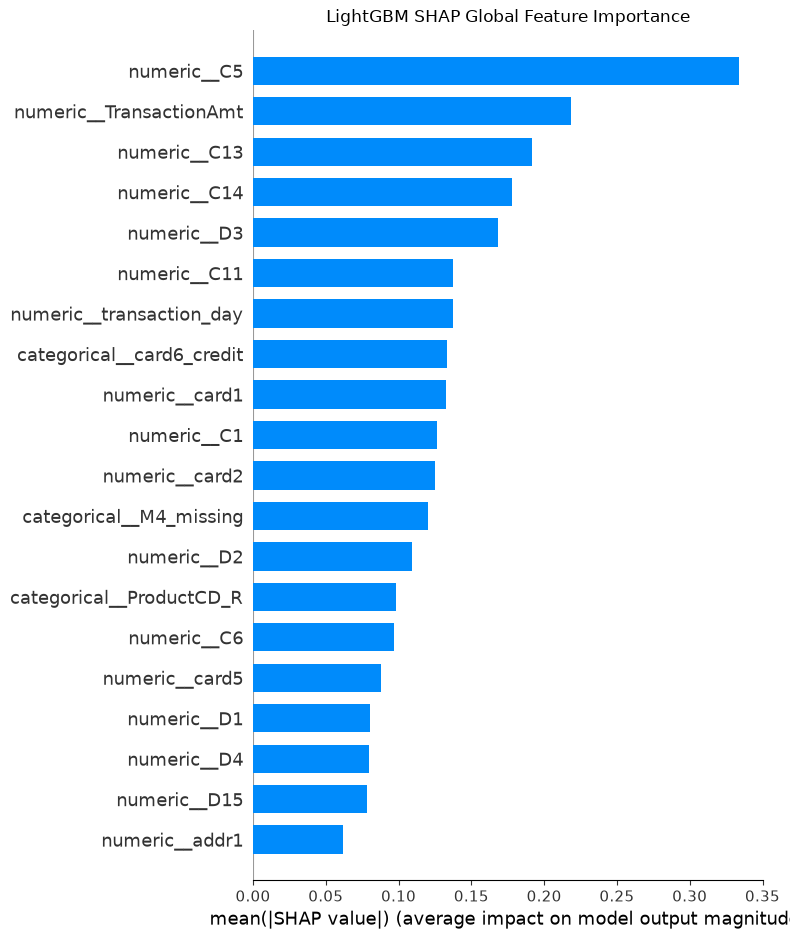

Figure saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures\lightgbm_shap_summary_bar.png


In [11]:
def plot_shap_summary_bar(
    shap_values,
    transformed_features,
    feature_names: list[str],
) -> None:
    shap.summary_plot(
        shap_values,
        transformed_features,
        feature_names=feature_names,
        plot_type="bar",
        max_display=20,
        show=False,
    )
    plt.title("LightGBM SHAP Global Feature Importance")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "lightgbm_shap_summary_bar.png", bbox_inches="tight")
    plt.show()


plot_shap_summary_bar(shap_values, transformed_sample, feature_names)
print(f"Figure saved to: {FIGURES_DIR / 'lightgbm_shap_summary_bar.png'}")

## 10. SHAP beeswarm plot

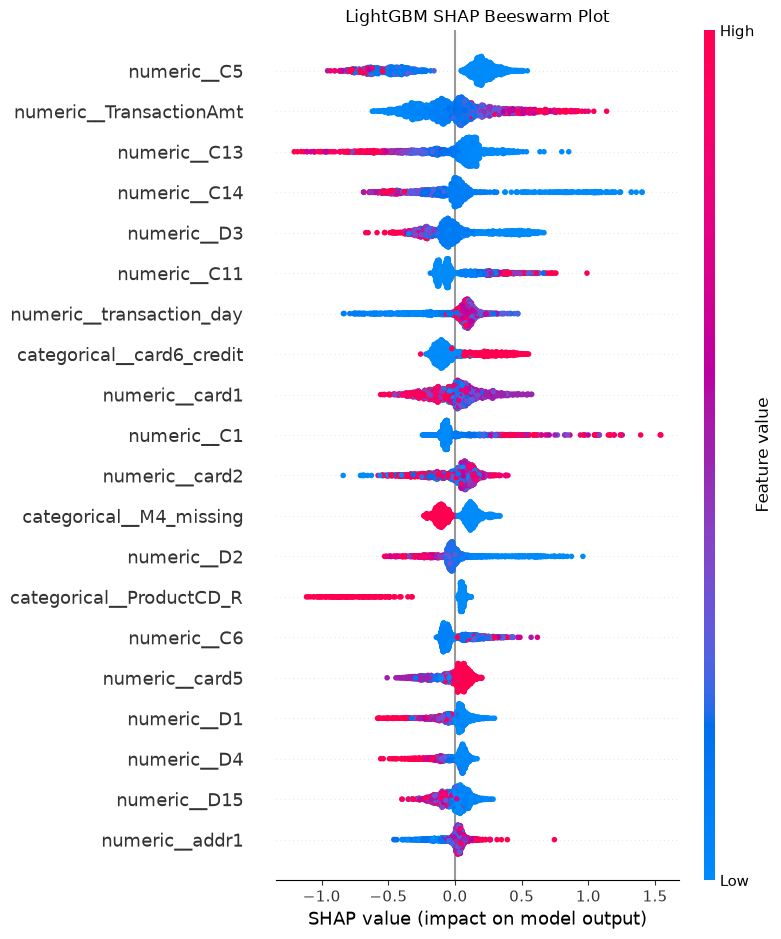

Figure saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\figures\lightgbm_shap_beeswarm.png


In [12]:
def plot_shap_beeswarm(
    shap_values,
    transformed_features,
    feature_names: list[str],
) -> None:
    shap.summary_plot(
        shap_values,
        transformed_features,
        feature_names=feature_names,
        max_display=20,
        show=False,
    )
    plt.title("LightGBM SHAP Beeswarm Plot")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "lightgbm_shap_beeswarm.png", bbox_inches="tight")
    plt.show()


plot_shap_beeswarm(shap_values, transformed_sample, feature_names)
print(f"Figure saved to: {FIGURES_DIR / 'lightgbm_shap_beeswarm.png'}")

## 11. Local explanations for the highest-risk test cases

In [13]:
def create_local_explanations(
    model_pipeline,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    feature_names: list[str],
) -> pd.DataFrame:
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]
    high_risk_positions = np.argsort(y_proba)[-LOCAL_CASE_COUNT:][::-1]
    X_cases = X_test.iloc[high_risk_positions]
    y_cases = y_test.iloc[high_risk_positions]
    y_proba_cases = y_proba[high_risk_positions]
    transformed_cases = transform_features(model_pipeline, X_cases)
    shap_values_cases = calculate_shap_values(model_pipeline, transformed_cases)

    records = []
    for case_number, position in enumerate(range(len(X_cases)), start=1):
        case_shap_values = shap_values_cases[position]
        top_feature_indices = np.argsort(np.abs(case_shap_values))[-TOP_LOCAL_FEATURES:][::-1]
        for rank, feature_index in enumerate(top_feature_indices, start=1):
            records.append(
                {
                    "case_number": case_number,
                    "true_label": int(y_cases.iloc[position]),
                    "predicted_fraud_probability": float(y_proba_cases[position]),
                    "rank": rank,
                    "feature": feature_names[feature_index],
                    "shap_value": float(case_shap_values[feature_index]),
                    "impact_direction": (
                        "increases_fraud_risk"
                        if case_shap_values[feature_index] > 0
                        else "decreases_fraud_risk"
                    ),
                }
            )
    return pd.DataFrame(records)


local_explanations_df = create_local_explanations(
    model_pipeline,
    X_test,
    y_test,
    feature_names,
)
local_explanations_df.to_csv(LOCAL_EXPLANATIONS_FILE, index=False)
print(f"Local explanations saved to: {LOCAL_EXPLANATIONS_FILE}")
local_explanations_df.head(30)

c:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Local explanations saved to: C:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\reports\model_reports\lightgbm_local_explanations.csv


c:\Users\Tinovimbanashe.Shaya\justcorp-sentinel-ai\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


,case_number,true_label,predicted_fraud_probability,rank,feature,shap_value,impact_direction
0,1,1,0.998954,1,numeric__V156,1.728617,increases_fraud_risk
1,1,1,0.998954,2,numeric__V258,0.974007,increases_fraud_risk
2,1,1,0.998954,3,numeric__C1,0.737024,increases_fraud_risk
3,1,1,0.998954,4,numeric__C11,0.564486,increases_fraud_risk
4,1,1,0.998954,5,numeric__V189,0.479819,increases_fraud_risk
5,1,1,0.998954,6,numeric__C5,0.475351,increases_fraud_risk
6,1,1,0.998954,7,numeric__C13,0.423974,increases_fraud_risk
7,1,1,0.998954,8,numeric__V201,0.374643,increases_fraud_risk
8,1,1,0.998954,9,numeric__C8,0.368848,increases_fraud_risk
9,1,1,0.998954,10,numeric__V158,-0.341074,decreases_fraud_risk


## 12. Summary

In [14]:
print("LightGBM SHAP Explainability Report")
print("=" * 80)
print(f"SHAP sample size: {sample_size}")
print()
print("Top 20 global SHAP features:")
print(importance_df.head(20))
print()
print("Local explanations for high-risk cases:")
print(local_explanations_df.head(30))
print()
print(f"SHAP feature importance saved to: {SHAP_IMPORTANCE_FILE}")
print(f"Local explanations saved to: {LOCAL_EXPLANATIONS_FILE}")
print(f"Figures saved to: {FIGURES_DIR}")

LightGBM SHAP Explainability Report
SHAP sample size: 2000

Top 20 global SHAP features:
                       feature  mean_absolute_shap_value
10                 numeric__C5                  0.333706
0      numeric__TransactionAmt                  0.218146
18                numeric__C13                  0.191896
19                numeric__C14                  0.177700
22                 numeric__D3                  0.168614
16                numeric__C11                  0.137297
57    numeric__transaction_day                  0.137278
73   categorical__card6_credit                  0.133597
1               numeric__card1                  0.132424
7                  numeric__C1                  0.126106
2               numeric__card2                  0.125224
121    categorical__M4_missing                  0.120309
21                 numeric__D2                  0.108991
65    categorical__ProductCD_R                  0.098381
11                 numeric__C6                  0.096654